In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
class QuantumSimulator:
    
    def __init__(self, num_qubits: int):
        self.num_qubits = num_qubits
        self.dim = 2 ** num_qubits
        self.reset()
        
        # Fundamental single-qubit gate matrices
        self.I = np.array([[1, 0], [0, 1]], dtype=complex)
        self.H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
        self.X = np.array([[0, 1], [1, 0]], dtype=complex)
        self.Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
        self.Z = np.array([[1, 0], [0, -1]], dtype=complex)
        
        # Projection operators for CNOT logic
        self.P0 = np.array([[1, 0], [0, 0]], dtype=complex)
        self.P1 = np.array([[0, 0], [0, 1]], dtype=complex)

    def reset(self):
        """Resets the quantum state vector to |00...0>."""
        self.state = np.zeros(self.dim, dtype=complex)
        self.state[0] = 1.0 + 0.0j

    def _build_single_qubit_operator(self, gate: np.ndarray, target: int) -> np.ndarray:
        """Constructs the full 2^n x 2^n unitary matrix using Kronecker products."""
        if target < 0 or target >= self.num_qubits:
            raise ValueError(f"Target qubit {target} out of range [0, {self.num_qubits-1}].")
            
        operators = [self.I] * self.num_qubits
        operators[target] = gate
        
        global_operator = operators[0]
        for op in operators[1:]:
            global_operator = np.kron(global_operator, op)
            
        return global_operator

    def apply_gate(self, gate_name: str, target: int):
        """Applies a named single-qubit gate ('H', 'X', 'Y', 'Z') to the target qubit."""
        gates = {'H': self.H, 'X': self.X, 'Y': self.Y, 'Z': self.Z}
        if gate_name not in gates:
            raise ValueError(f"Gate {gate_name} not supported.")
            
        gate_matrix = gates[gate_name]
        global_op = self._build_single_qubit_operator(gate_matrix, target)
        self.state = global_op @ self.state

    def apply_cnot(self, control: int, target: int):
        """Applies a Controlled-NOT (CNOT) gate across specified control and target qubits."""
        if control == target:
            raise ValueError("Control and target qubits cannot be the same.")
        if not (0 <= control < self.num_qubits) or not (0 <= target < self.num_qubits):
            raise ValueError("Qubit index out of bounds.")

        # Term 1: Control is |0> -> Target unaffected
        ops_term1 = [self.I] * self.num_qubits
        ops_term1[control] = self.P0
        term1_matrix = ops_term1[0]
        for op in ops_term1[1:]:
            term1_matrix = np.kron(term1_matrix, op)

        # Term 2: Control is |1> -> Apply X to target
        ops_term2 = [self.I] * self.num_qubits
        ops_term2[control] = self.P1
        ops_term2[target] = self.X
        term2_matrix = ops_term2[0]
        for op in ops_term2[1:]:
            term2_matrix = np.kron(term2_matrix, op)

        cnot_global = term1_matrix + term2_matrix
        self.state = cnot_global @ self.state

    def measure(self) -> str:
        """Measures the quantum state, collapses the state vector, and returns classical bits."""
        probabilities = np.abs(self.state) ** 2
        probabilities /= np.sum(probabilities)
        
        basis_states = np.arange(self.dim)
        measured_index = np.random.choice(basis_states, p=probabilities)
        
        # Collapse the wave function
        self.state = np.zeros(self.dim, dtype=complex)
        self.state[measured_index] = 1.0 + 0.0j
        
        binary_format = f"0{self.num_qubits}b"
        return format(measured_index, binary_format)

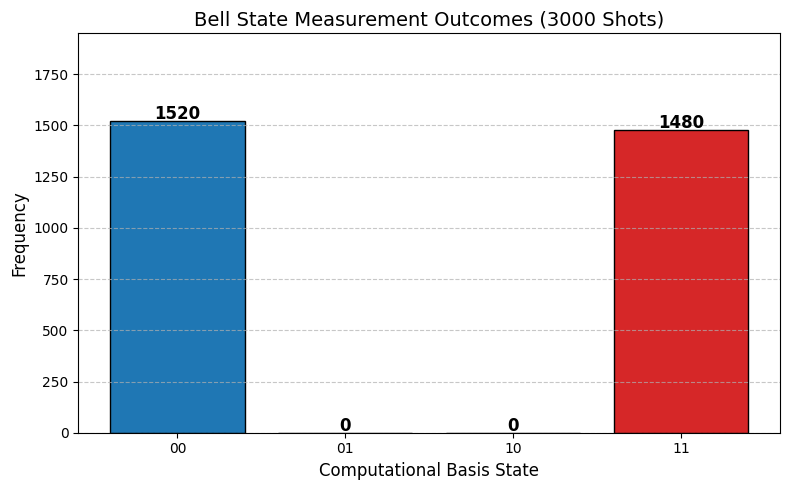

In [11]:
def run_bell_state_experiment(shots: int = 3000):
    sim = QuantumSimulator(num_qubits=2)
    results = {'00': 0, '01': 0, '10': 0, '11': 0}
    
    for _ in range(shots):
        sim.reset()
        sim.apply_gate('H', target=0)
        sim.apply_cnot(control=0, target=1)
        outcome = sim.measure()
        results[outcome] += 1
        
    return results

# Run simulation
shots = 3000
measurement_results = run_bell_state_experiment(shots)

# Plot histogram
states = list(measurement_results.keys())
counts = list(measurement_results.values())

plt.figure(figsize=(8, 5))
plt.bar(states, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='black')
plt.title(f"Bell State Measurement Outcomes ({shots} Shots)", fontsize=14)
plt.xlabel("Computational Basis State", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.ylim(0, shots * 0.65)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, count in enumerate(counts):
    plt.text(i, count + 10, str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()